# LOADING LIBRARIES & DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path_to_repo = Path('..').resolve()
path_to_data = path_to_repo / 'data'

app = pd.read_csv(path_to_data / 'application_record.csv')
credit = pd.read_csv(path_to_data / 'credit_record.csv')


print("App shape:", app.shape)
print("Credit shape:", credit.shape)

display(app.head())
display(credit.head())

App shape: (438557, 18)
Credit shape: (1048575, 3)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
credit["STATUS_NUM"] = credit["STATUS"].replace({"X":0, "C":0}).astype(int)
credit["bad"] = (credit["STATUS_NUM"] >= 2).astype(int)
credit_sorted = credit.sort_values(["ID","MONTHS_BALANCE"])

In [ ]:
credit_agg = credit_sorted.groupby("ID").agg(
    months_observed = ("MONTHS_BALANCE","count"),
    worst_status    = ("STATUS_NUM","max"),
    any_bad         = ("bad","max"),
).reset_index()

In [ ]:
def last_n_months(df, n):
    return df.groupby("ID").apply(
        lambda x: x.nlargest(n, "MONTHS_BALANCE")["STATUS_NUM"].max()
    )

credit_last3  = last_n_months(credit_sorted, 3).rename("worst_last3")
credit_last6  = last_n_months(credit_sorted, 6).rename("worst_last6")
credit_last12 = last_n_months(credit_sorted, 12).rename("worst_last12")

credit_windows = pd.concat([credit_last3, credit_last6, credit_last12], axis=1).reset_index()

C:\Users\Arystan\AppData\Local\Temp\ipykernel_10940\527351617.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("ID").apply(
C:\Users\Arystan\AppData\Local\Temp\ipykernel_10940\527351617.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("ID").apply(
C:\Users\Arystan\AppData\Local\Temp\ipykernel_10940\527351617.py:2: DeprecationWarning: DataFrameGroupBy.apply operated 

In [ ]:
app["AGE"] = (-app["DAYS_BIRTH"] / 365).astype(int)
app["EXP"] = app["DAYS_EMPLOYED"].apply(lambda x: 0 if x > 0 else int(-x/365))
app["CNT_FAM_MEMBERS"] = app["CNT_FAM_MEMBERS"].round().astype(int)

app = app.drop(columns=["DAYS_BIRTH","DAYS_EMPLOYED"])

In [17]:
df = app.merge(credit_agg, on="ID", how="left")
df = df.merge(credit_windows, on="ID", how="left")
df = df.fillna(0)
df.shape

(438557, 24)

In [28]:
print("Age < 18:", (df["AGE"] < 18).sum())
print("Experience > Age:", (df["EXP"] > df["AGE"]).sum())
print("Children > family size:", (df["CNT_CHILDREN"] > df["CNT_FAM_MEMBERS"]).sum())

Age < 18: 0
Experience > Age: 0
Children > family size: 41


In [29]:
mask = df["CNT_CHILDREN"] > df["CNT_FAM_MEMBERS"]
df.loc[mask, "CNT_FAM_MEMBERS"] = df.loc[mask, "CNT_CHILDREN"] + 1

# GENERAL EDA

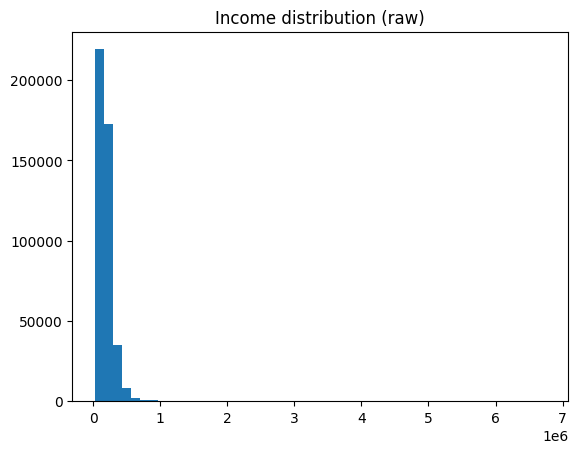

In [32]:
plt.hist(df["AMT_INCOME_TOTAL"], bins=50)
plt.title("Income distribution (raw)")
plt.show()

##### <b>Conclusion: </b>The raw income distribution is extremely right-skewed, with most applicants concentrated in the lower income range. A small number of clients have very high incomes
Because of this skewness, applying a logarithmic transformation (log or log1p) is necessary to normalize the distribution and reduce the impact of extreme income values on the model.

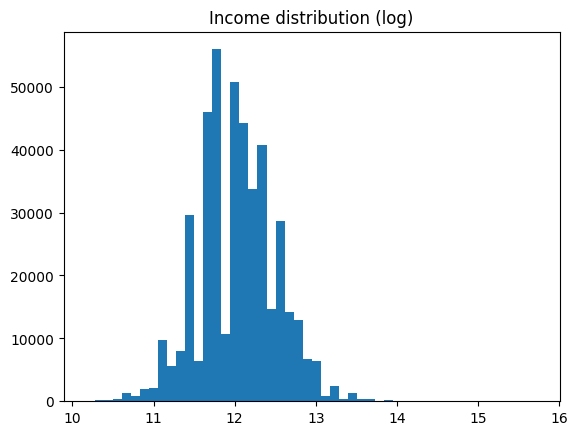

In [33]:
plt.hist(np.log1p(df["AMT_INCOME_TOTAL"]), bins=50)
plt.title("Income distribution (log)")
plt.show()

#### After applying a log transformation, the income distribution becomes much more symmetric and closer to a bell shape. This indicates that the log scale effectively reduces the influence of extreme high-income values and stabilizes variance

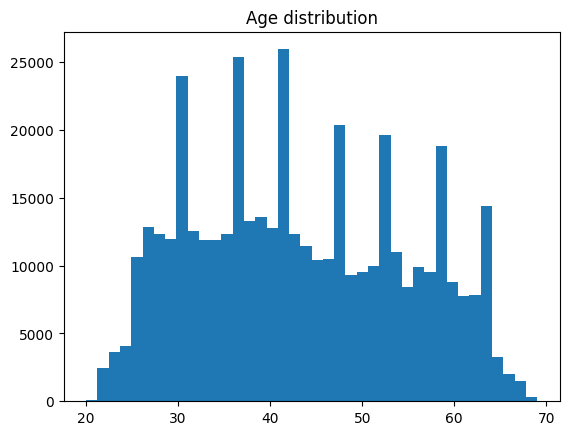

In [34]:
plt.hist(df["AGE"], bins=40)
plt.title("Age distribution")
plt.show()


#### The age distribution shows that most applicants fall within the 25–65 age range, with very few clients younger than 25 or older than 65. The distribution is fairly uniform across the working-age population

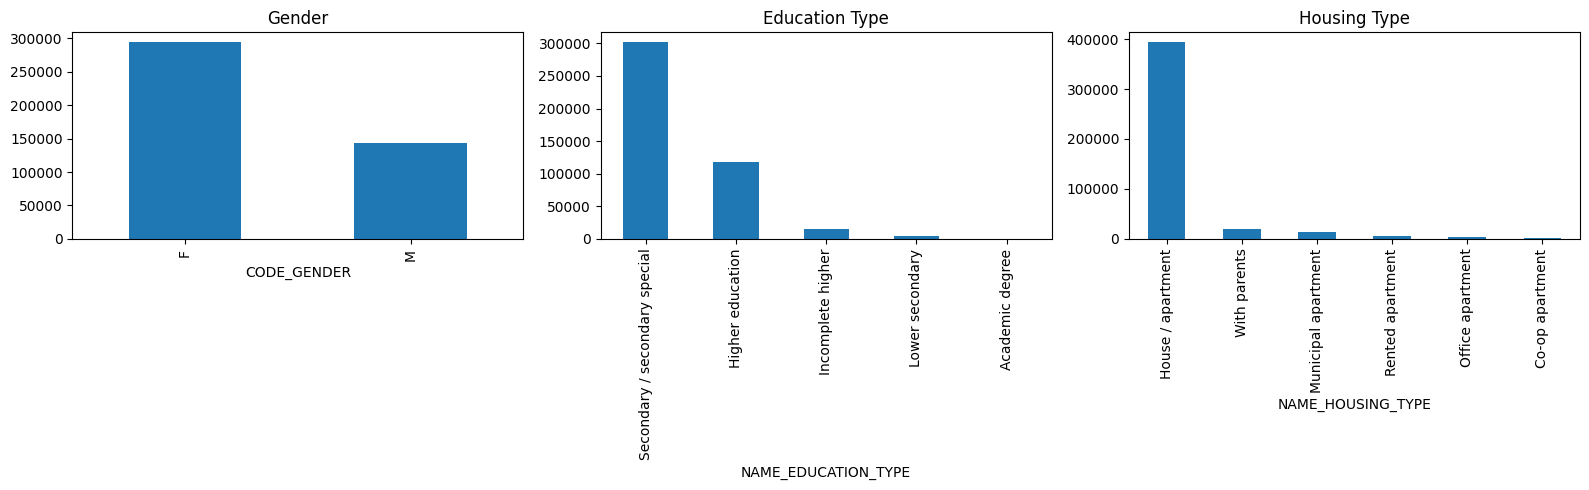

In [35]:
fig, ax = plt.subplots(1,3, figsize=(16,5))

df["CODE_GENDER"].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Gender")

df["NAME_EDUCATION_TYPE"].value_counts().plot(kind="bar", ax=ax[1])
ax[1].set_title("Education Type")

df["NAME_HOUSING_TYPE"].value_counts().plot(kind="bar", ax=ax[2])
ax[2].set_title("Housing Type")

plt.tight_layout()
plt.show()

#### 1. The gender distribution shows that the dataset contains significantly more female applicants than male applicants

#### 2. The majority of applicants have Secondary/Secondary special education, followed by Higher education. Other education levels represent a very small portion of the data.

#### 3. Most applicants live in a House/apartment, while all other housing categories appear far less frequently

# CREDIT STATUS ANALYSIS

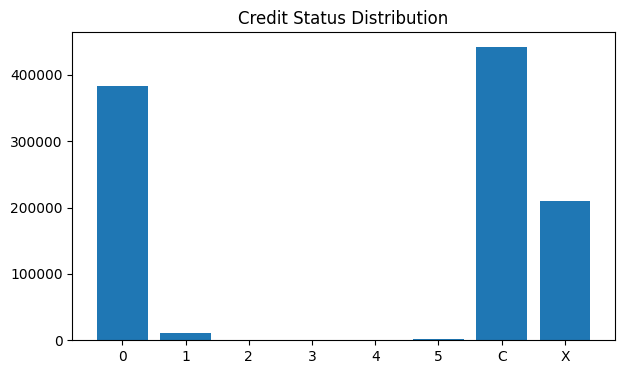

In [ ]:
status_counts = credit["STATUS"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(status_counts.index, status_counts.values)
plt.title("Credit Status Distribution")
plt.show()

#### Most records fall into the categories “0”, “C”, and “X”, which represent fully paid, closed, or inactive accounts. This indicates that the majority of clients either meet their payment obligations or have no active credit at the moment of observation.

#### Statuses 1–5, which reflect increasing levels of payment delay or delinquency, appear very rarely. Status ≥ 2 is extremely uncommon in the dataset

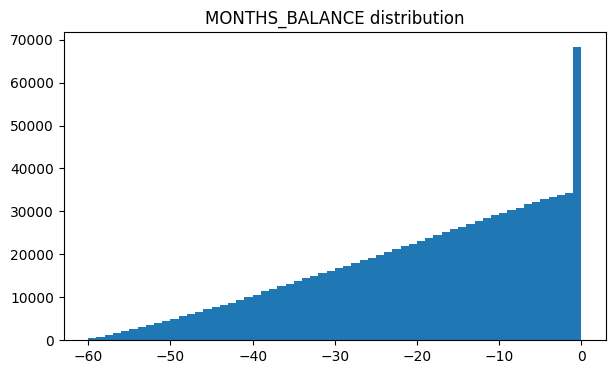

In [23]:
plt.figure(figsize=(7,4))
plt.hist(credit["MONTHS_BALANCE"], bins=60)
plt.title("MONTHS_BALANCE distribution")
plt.show()

#### The values are negative because they represent the number of months before the current moment, where 0 corresponds to the most recent month, and -60 represents the earliest available record.
The histogram increases toward zero, indicating that more recent months contain more active credit entries. This is expected, as older records gradually fall out of reporting windows.

# TARGET EDA

any_bad
0.0    0.998595
1.0    0.001405
Name: proportion, dtype: float64


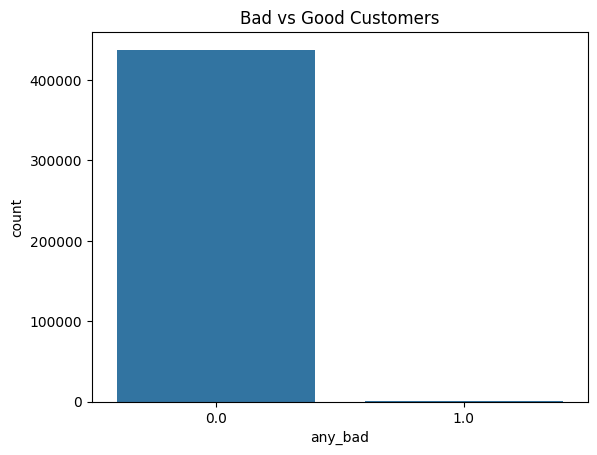

In [ ]:
sns.countplot(x=df["any_bad"])
plt.title("Bad vs Good Customers")
plt.show()
print(df["any_bad"].value_counts(normalize=True))

#### The target distribution is extremely imbalanced
Only 0.14% of customers are classified as bad (where status ≥ 2), while 99.86% are good. This means that true delinquency events are very rare in the dataset

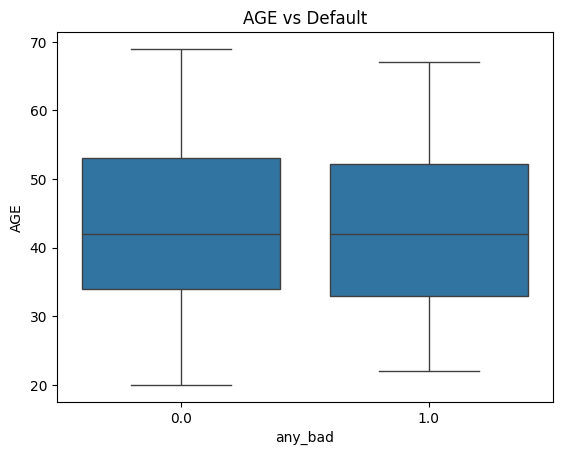

In [ ]:
sns.boxplot(x=df["any_bad"], y=df["AGE"])
plt.title("AGE vs Default")
plt.show()

#### The boxplot shows that the age distributions of good and bad customers are very similar. Both groups have nearly identical medians and interquartile ranges
There is no strong difference in age between delinquent and non-delinquent clients

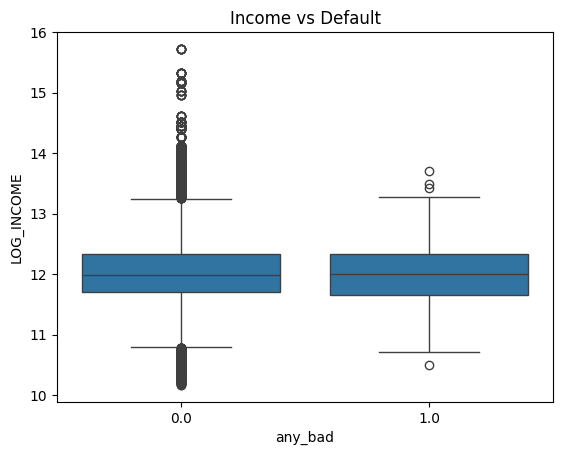

In [12]:
df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])
sns.boxplot(x=df["any_bad"], y=df["LOG_INCOME"])
plt.title("Income vs Default")
plt.show()

#### The boxplot shows that the log income distributions for good and bad customers are broadly similar, with almost identical medians and interquartile ranges. However, good customers display a noticeably larger number of outliers, while bad customers tend to cluster more tightly around the lower-middle income range

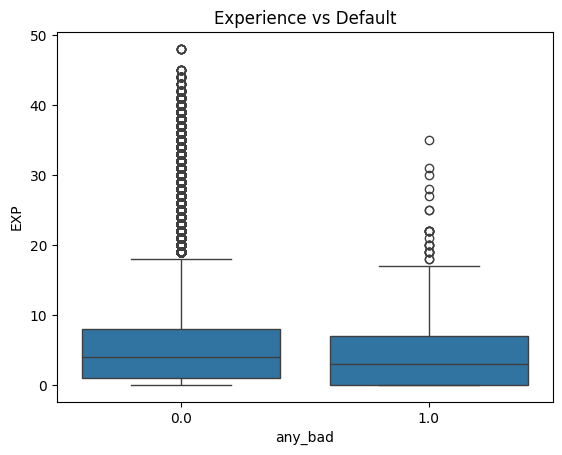

In [13]:
sns.boxplot(x=df["any_bad"], y=df["EXP"])
plt.title("Experience vs Default")
plt.show()

#### The boxplot shows that the work experience of good and bad customers follows a very similar distribution. Both groups have almost identical medians and interquartile ranges, which means that employment duration does not differ substantially between delinquent and non-delinquent clients

The only noticeable pattern is that good customers have more high-experience outliers

# TIME WINDOW RISK ANALYSIS

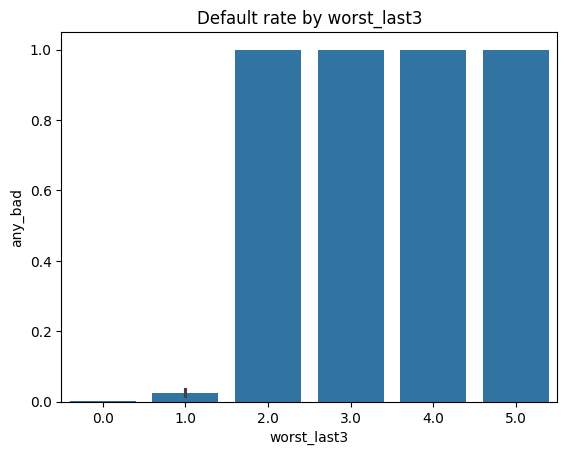

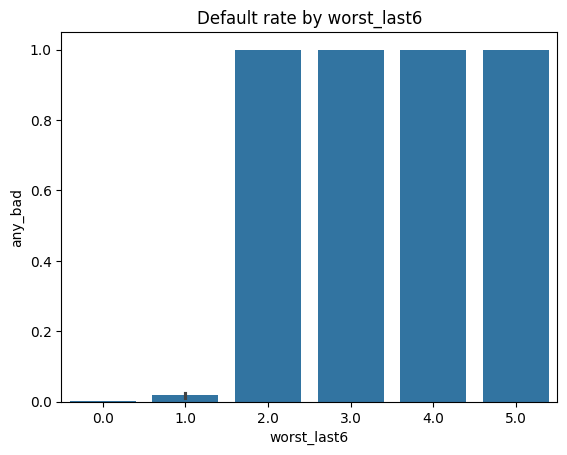

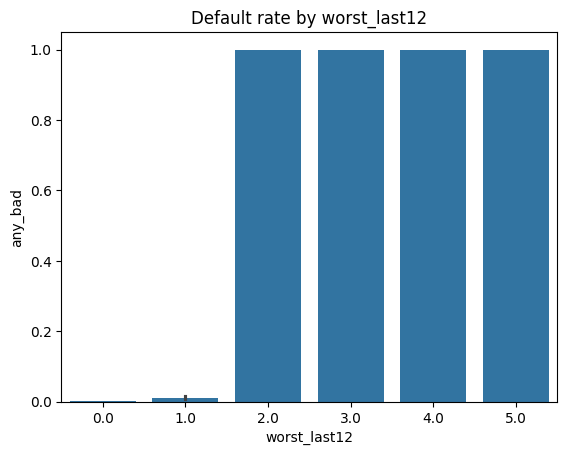

In [14]:
for col in ["worst_last3","worst_last6","worst_last12"]:
    sns.barplot(x=df[col], y=df["any_bad"])
    plt.title(f"Default rate by {col}")
    plt.show()

#### 1. Customers with only 0 (no delays) have almost zero default rate
#### 2. Customers with status = 1 still show very low default risk
#### 3. Customers with status ≥ 2 results in nearly 100% default probability
#### 4. Stability across windows (3 vs 6 vs 12 months)
The shape of all three graphs is nearly identical. The moment the worst status reaches 2, 3, 4, or 5, the default rate jumps to almost exactly 1.0 in every window

# Correlation analysis

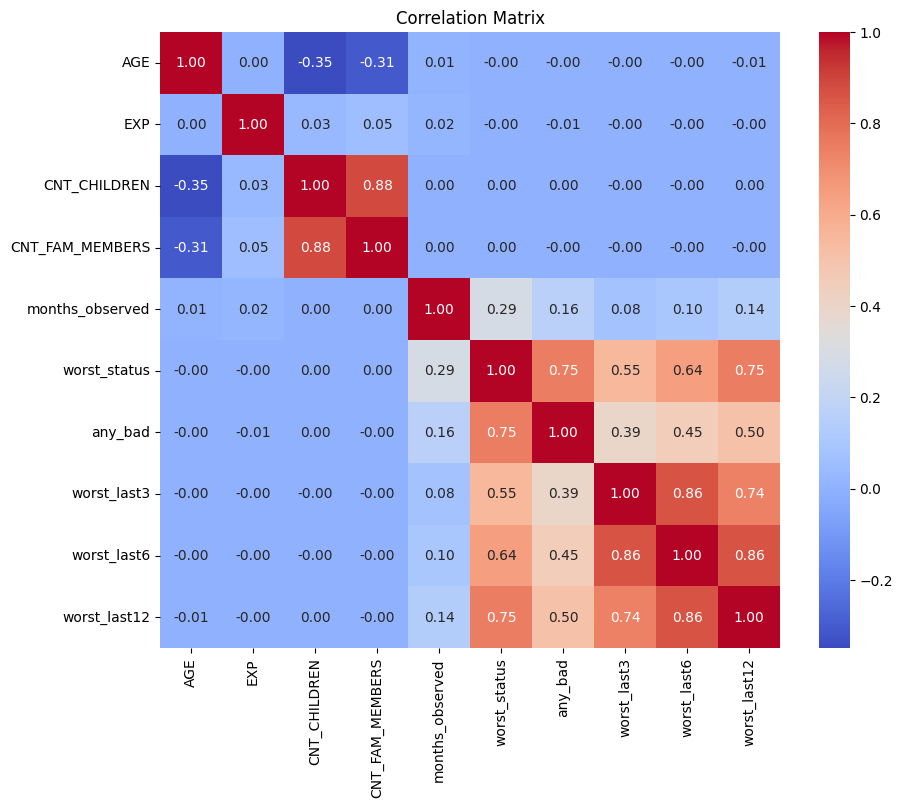

In [15]:
corr = df[[
    "AGE","EXP","CNT_CHILDREN","CNT_FAM_MEMBERS",
    "months_observed","worst_status","any_bad",
    "worst_last3","worst_last6","worst_last12"
]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### 1. Features such as AGE, EXP, CNT_CHILDREN, and CNT_FAM_MEMBERS show only weak correlations with default-related variables
#### 2. months_observed has moderate correlation with worst_status (0.29)
Clients with longer credit histories tend to exhibit slightly worse maximum delinquency, but the effect is weak

# CONCLUSION

#### Overall, the exploratory data analysis reveals a clear separation between weakly informative demographic attributes and highly predictive credit-behaviour features. Age, employment length, income, and family composition show only marginal relationships with delinquency, indicating that these factors alone provide limited insight into a client’s true creditworthiness. In contrast, variables derived from historical credit behaviour, such as worst observed status, frequency of delinquencies, and recent payment performance, demonstrate strong internal correlations and a direct, consistent relationship with default risk.